# Truncated Analysis


In [3]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_npy_file_truncated
from reset_folder_notebook import reset_folder 


Call the directory where the traces are saved and the result directory 

In [4]:
truncated_registers = ["r2", "r3", "r4", "r5", "r6"]
truncated_trace_dir = "output_decapsulation_truncated_TRIM"
result_dir_truncated = "Results_decapsulation_truncated"
no_instructions = 100 
selected_fault_index = 0
reset_folder(result_dir_truncated)

os.makedirs(result_dir_truncated, exist_ok=True)

create_npy_file_truncated(f"{result_dir_truncated}/HW_SUBTRACE", truncated_trace_dir, "HW", truncated_registers, selected_fault_index)
create_npy_file_truncated(f"{result_dir_truncated}/HD_SUBTRACE", truncated_trace_dir, "HD", truncated_registers, selected_fault_index)

data_HW_by_register = {}
# create one .npy file per register and per xs_id, and load them into a dictionary
for reg in truncated_registers:
    create_npy_file_truncated(
        f"{result_dir_truncated}/HW_SUBTRACE_{reg}",
        truncated_trace_dir,
        "HW",
        [reg],
        selected_fault_index,
    )

    data_HW_by_register[reg] = {}

    for file in sorted(Path(result_dir_truncated).glob(f"HW_SUBTRACE_{reg}_xs*.npy")):
        match = re.search(r"xs(\d+)", file.stem)
        xs = int(match.group(1))
        data_HW_by_register[reg][xs] = np.load(file)

create_npy_file_truncated(
    f"{result_dir_truncated}/HW_SUBTRACE_r0",
    truncated_trace_dir,
    "HW",
    ["r0"],
    selected_fault_index,
)
create_npy_file_truncated(
    f"{result_dir_truncated}/HD_SUBTRACE_r0",
    truncated_trace_dir,
    "HD",
    ["r0"],
    selected_fault_index,
)



Creating simulation traces model.... HW
Found 640 truncated trace files for fault_index=0
Trace 0 has been converted
Trace row 0 for xs=0, fault=0 -> trace_0_0_0.csv
Trace row 0 for xs=1, fault=0 -> trace_0_1_0.csv
Trace row 0 for xs=2, fault=0 -> trace_0_2_0.csv
Trace row 0 for xs=3, fault=0 -> trace_0_3_0.csv
Trace row 0 for xs=4, fault=0 -> trace_0_4_0.csv
Trace row 0 for xs=5, fault=0 -> trace_0_5_0.csv
Trace row 0 for xs=6, fault=0 -> trace_0_6_0.csv
Trace row 0 for xs=7, fault=0 -> trace_0_7_0.csv
Trace row 1 for xs=0, fault=0 -> trace_1_0_0.csv
Trace row 1 for xs=1, fault=0 -> trace_1_1_0.csv
Trace row 1 for xs=2, fault=0 -> trace_1_2_0.csv
Trace row 1 for xs=3, fault=0 -> trace_1_3_0.csv
Trace row 1 for xs=4, fault=0 -> trace_1_4_0.csv
Trace row 1 for xs=5, fault=0 -> trace_1_5_0.csv
Trace row 1 for xs=6, fault=0 -> trace_1_6_0.csv
Trace row 1 for xs=7, fault=0 -> trace_1_7_0.csv
Trace row 2 for xs=0, fault=0 -> trace_2_0_0.csv
Trace row 2 for xs=1, fault=0 -> trace_2_1_0.csv
T

In [5]:
data_HW_truncated = {}
print("Information HW truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_truncated[xs_id] = np.load(file)
    information(data_HW_truncated[xs_id])

data_HD_truncated = {}

print("\nInformation HD truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_truncated[xs_id] = np.load(file)
    information(data_HD_truncated[xs_id])

data_HW_r0 = {}
print("\nInformation HW r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_r0[xs_id] = np.load(file)
    information(data_HW_r0[xs_id])

data_HD_r0 = {}
print("\nInformation HD r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_r0[xs_id] = np.load(file)
    information(data_HD_r0[xs_id])



Information HW truncated
------------------------
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[44. 44. 44. ... 79. 79. 79.]
 [44. 44. 44. ... 60. 60. 60.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[68. 68. 68. ... 79. 79. 79.]
 [60. 60. 60. ... 60. 60. 60.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[68. 68. 68. ... 79. 79. 79.]
 [60. 60. 60. ... 60. 60. 60.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[68. 68. 68. ... 79. 79. 79.]
 [60. 60. 60. ... 60. 60. 60.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[68. 68. 68. ... 79. 79. 79.]
 [60. 60. 60. ... 60. 60. 60.]]
If there are any NaN valu

Load one B for each trace and all B for all the ciphertext that have been generated

In [6]:
def load_B(run_index, B_folder, prefix="B", fault_index=None):
    if fault_index is None:
        path = Path(B_folder) / f"{prefix}_{run_index}.csv"
    else:
        path = Path(B_folder) / f"{prefix}_{run_index}_{fault_index}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing B file: {path}")

    df = pd.read_csv(path)
    value_cols = [col for col in df.columns if col != "row"]
    return df[value_cols].to_numpy(dtype=np.float64)


def load_all_B(B_folder, prefix="B", fault_index=None):
    if fault_index is None:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)\.csv$")
    else:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)_{fault_index}\.csv$")

    files = []
    for path in Path(B_folder).glob(f"{prefix}_*.csv"):
        match = pattern.fullmatch(path.name)
        if match is not None:
            files.append((int(match.group(1)), path))

    files.sort(key=lambda item: item[0])

    if not files:
        suffix = "" if fault_index is None else f" for fault_index={fault_index}"
        raise FileNotFoundError(f"No {prefix}_*.csv files found in {B_folder}{suffix}")

    runs = [run_index for run_index, _ in files]
    B_all = np.array([
        load_B(run_index, B_folder, prefix=prefix, fault_index=fault_index)
        for run_index in runs
    ])
    return B_all, runs



Data for modified B
B_all shape: (80, 8, 640)
B_from_registers shape: (80, 8, 640)
B_packed_from_registers shape: (80, 8, 320)

Data for valid B
B_valid shape: (80, 8, 640)
B_valid_from_registers shape: (80, 8, 640)
B_valid_packed_from_registers shape: (80, 8, 320)



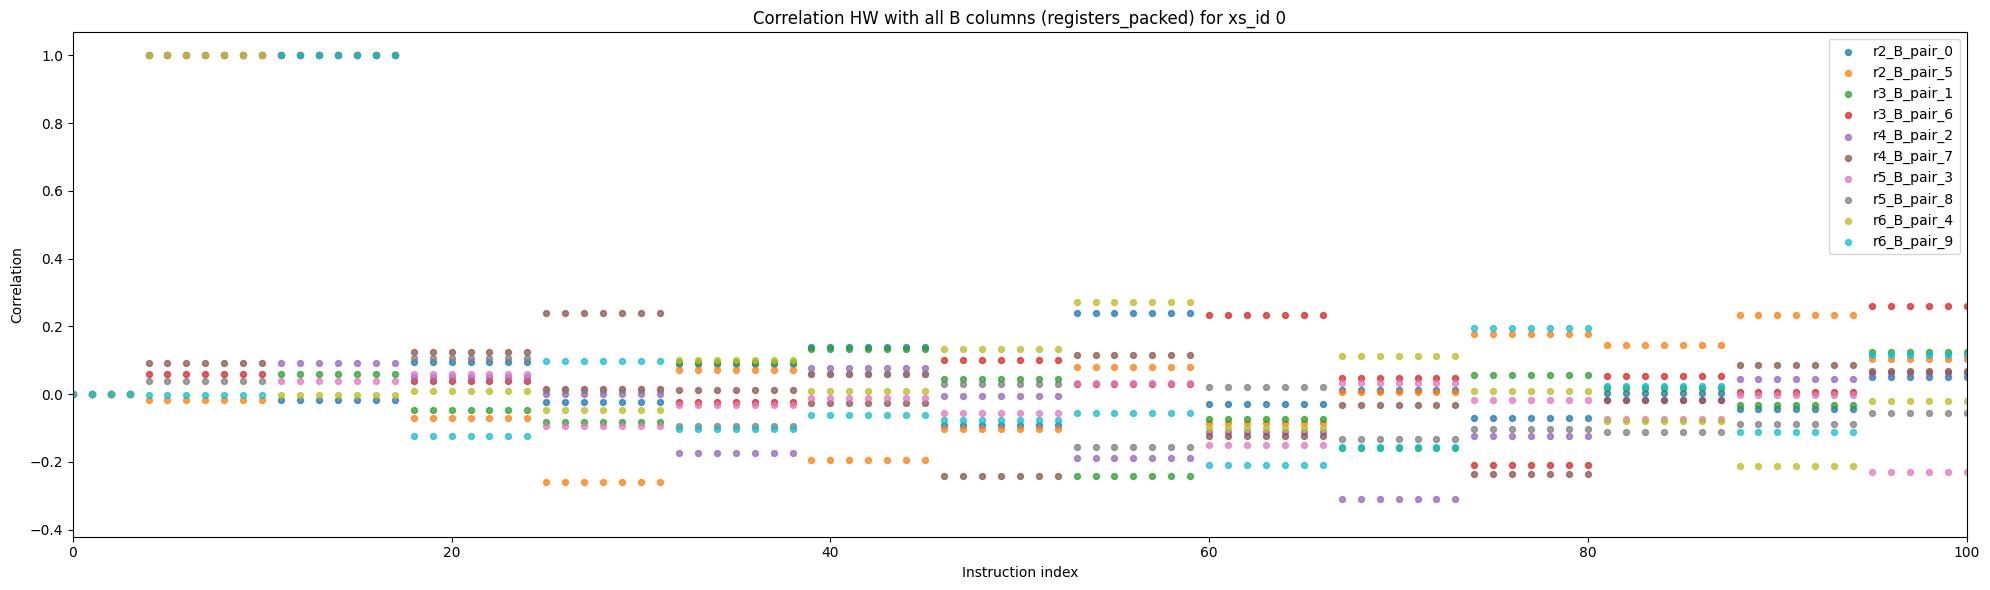

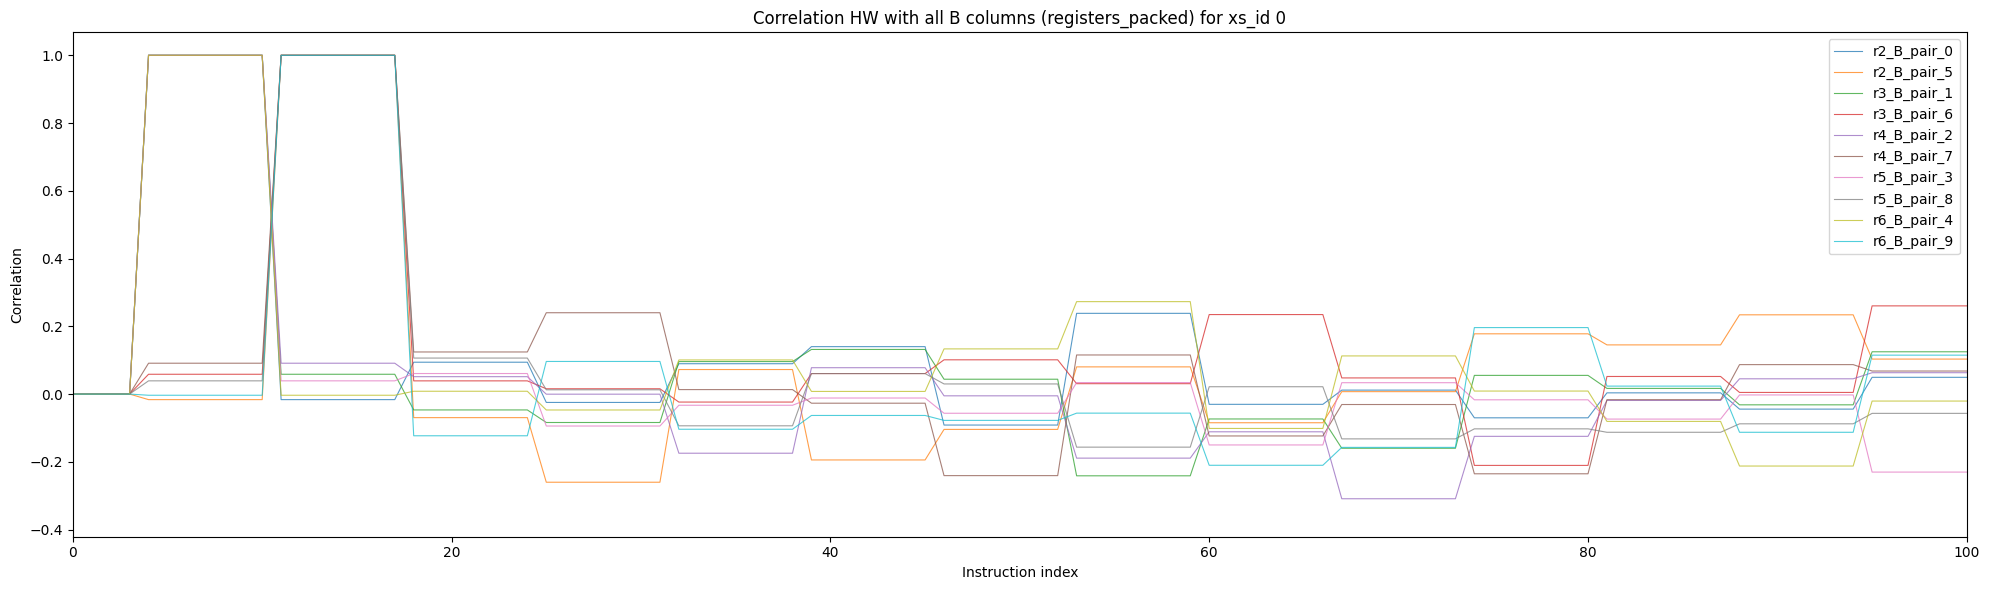

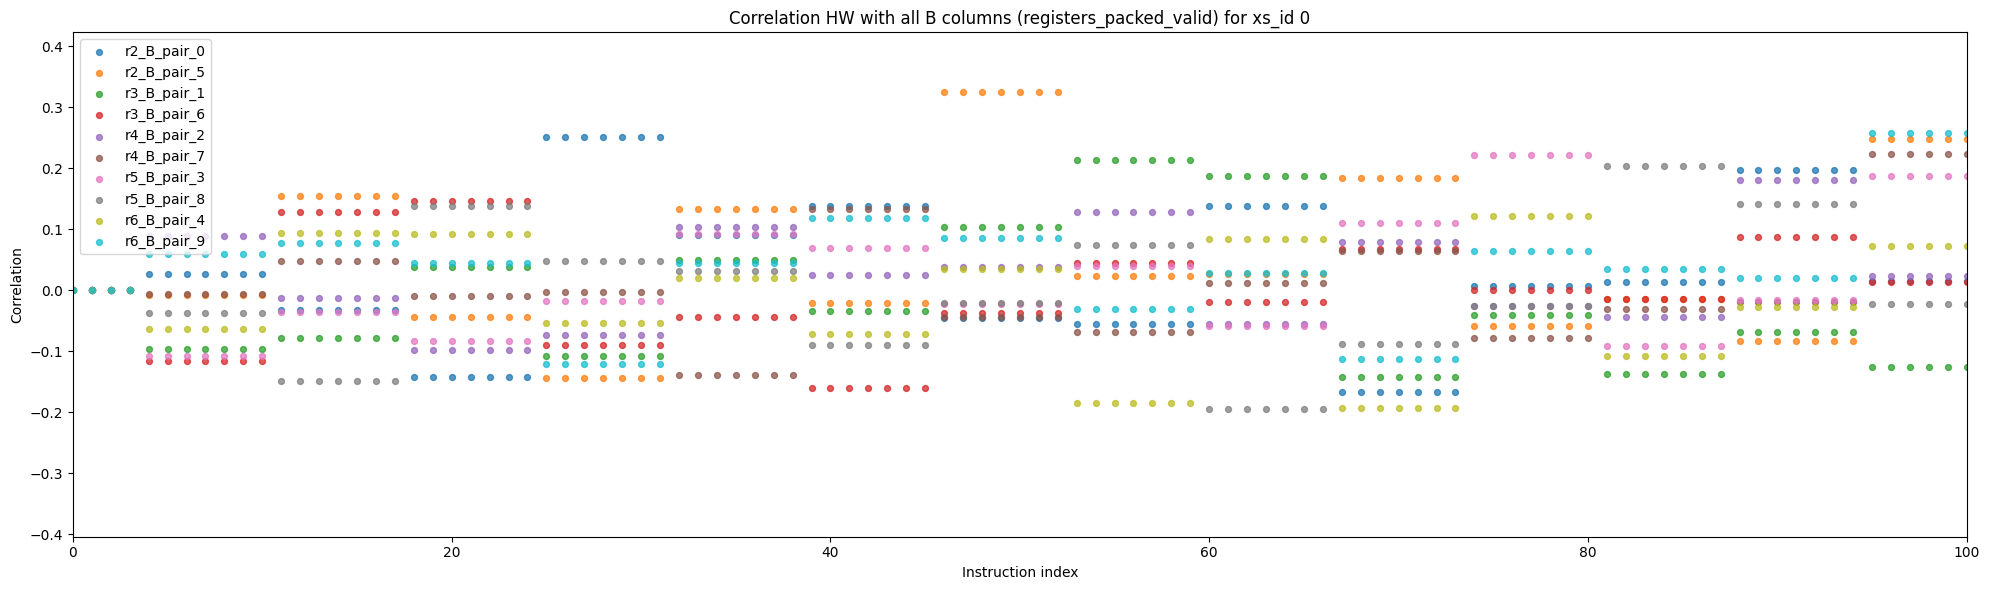

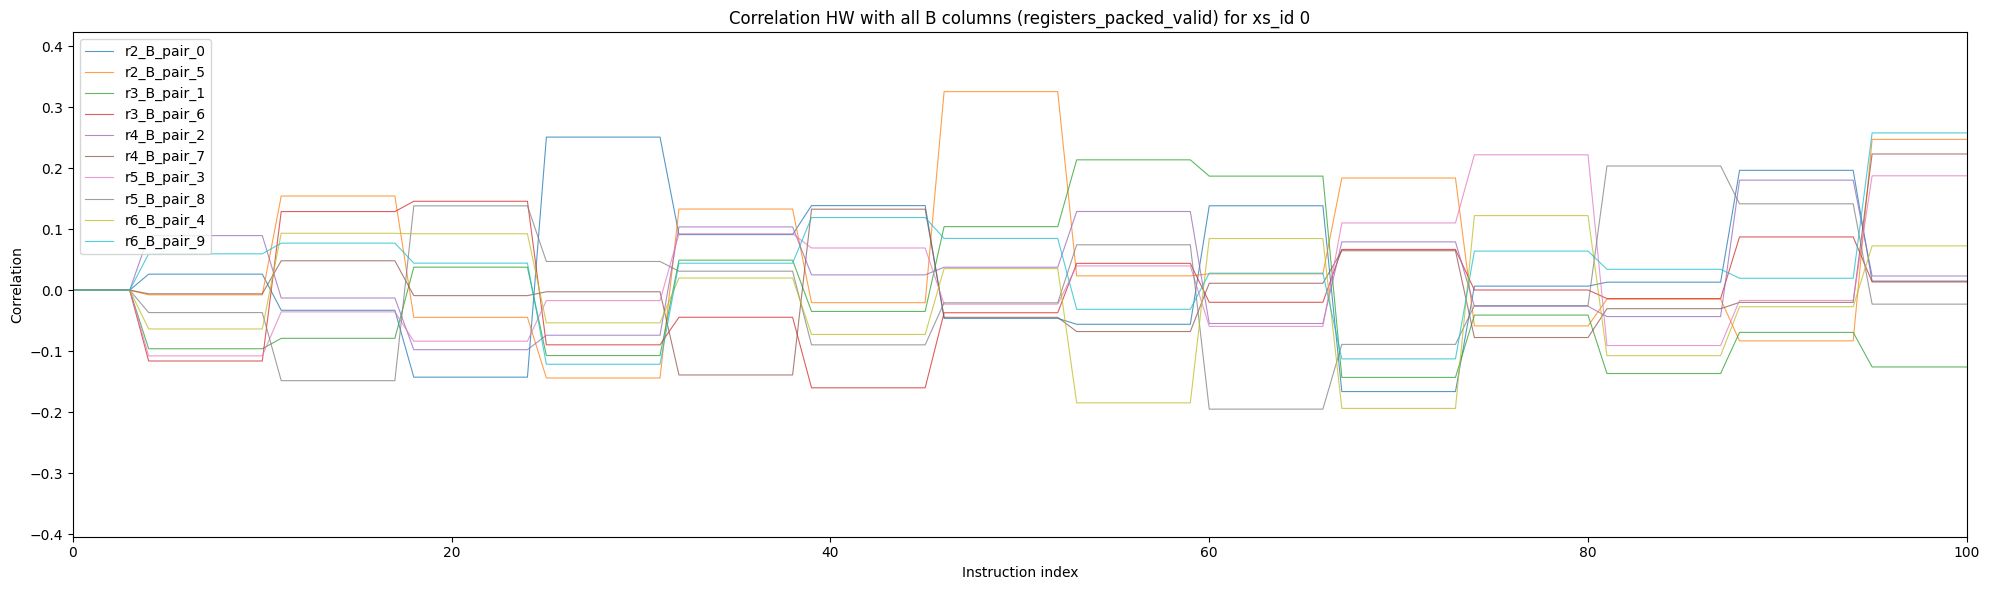

In [7]:
B_folder = Path("output_decapsulation_truncated/B")

B_all, B_runs = load_all_B(B_folder, prefix="B", fault_index=selected_fault_index)
B_valid, B_valid_runs = load_all_B(B_folder, prefix="B_valid")

B_from_registers, B_register_runs = load_all_B(B_folder, prefix="B_from_registers", fault_index=selected_fault_index)
B_valid_from_registers, B_valid_register_runs = load_all_B(B_folder, prefix="B_valid_from_registers")

B_packed_from_registers, B_packed_runs = load_all_B(B_folder, prefix="B_from_registers_packed", fault_index=selected_fault_index)
B_valid_packed_from_registers, B_valid_packed_runs = load_all_B(B_folder, prefix="B_valid_from_registers_packed")

print("\nData for modified B")
print("B_all shape:", B_all.shape)
print("B_from_registers shape:", B_from_registers.shape)
print("B_packed_from_registers shape:", B_packed_from_registers.shape)
print("\nData for valid B")
print("B_valid shape:", B_valid.shape)
print("B_valid_from_registers shape:", B_valid_from_registers.shape)
print("B_valid_packed_from_registers shape:", B_valid_packed_from_registers.shape)

print()

xs_id = 0
traces_hw = data_HW_truncated[xs_id]
traces_hd = data_HD_truncated[xs_id]

B_row = xs_id
no_B_cols = 10 

B_base = {
    # "ciphertext": B_all,
    # "registers": B_from_registers,
    "registers_packed": B_packed_from_registers,
}

B_valid_base = {
    # "ciphertext_valid": B_valid,
    # "registers_valid": B_valid_from_registers,
    "registers_packed_valid": B_valid_packed_from_registers,
}

for B_name, B_values in B_base.items():
    corr_hw_array = {}

    for B_col in range(no_B_cols):
        register_values = B_values[:, B_row, B_col]
        target_hw_values = hw_u32(register_values.astype(np.uint32))

        if B_name == "registers_packed":
            # register index is determined by the column index modulo the number of truncated registers -> look in Ghidra 
            reg_index = B_col % len(truncated_registers)
            reg = truncated_registers[reg_index]

            traces_hw_for_corr = data_HW_by_register[reg][xs_id]
            label = f"{reg}_B_pair_{B_col}"
        else:
            traces_hw_for_corr = traces_hw
            label = f"B_col_{B_col}"
   

        corr_hw_array[label] = compute_correlation(traces_hw_for_corr,target_hw_values)

    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}.png"),no_instructions=no_instructions, style="points", marker_size=18)
    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}_line.png"),no_instructions=no_instructions, style="line", marker_size=18)

for B_name, B_values in B_valid_base.items():
    corr_hw_array = {}

    for B_col in range(no_B_cols):
        register_values = B_values[:, B_row, B_col]
        target_hw_values = hw_u32(register_values.astype(np.uint32))

        if B_name == "registers_packed_valid":
            # register index is determined by the column index modulo the number of truncated registers -> look in Ghidra 
            reg_index = B_col % len(truncated_registers)
            reg = truncated_registers[reg_index]

            traces_hw_for_corr = data_HW_by_register[reg][xs_id]
            label = f"{reg}_B_pair_{B_col}"
        else:
            traces_hw_for_corr = traces_hw
            label = f"B_col_{B_col}"

        corr_hw_array[label] = compute_correlation(traces_hw_for_corr,target_hw_values)

    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}.png"),no_instructions=no_instructions, style="points", marker_size=18)
    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}_line.png"),no_instructions=no_instructions, style="line", marker_size=18)


In [8]:
S_df = pd.read_csv("output_decapsulation_truncated/S/S.csv")
S_real = S_df[[f"S_col_{j}" for j in range(8)]].to_numpy(dtype=np.int16)


Correlation between B[i] * S[i] +  B[i+1] * S[i+1]

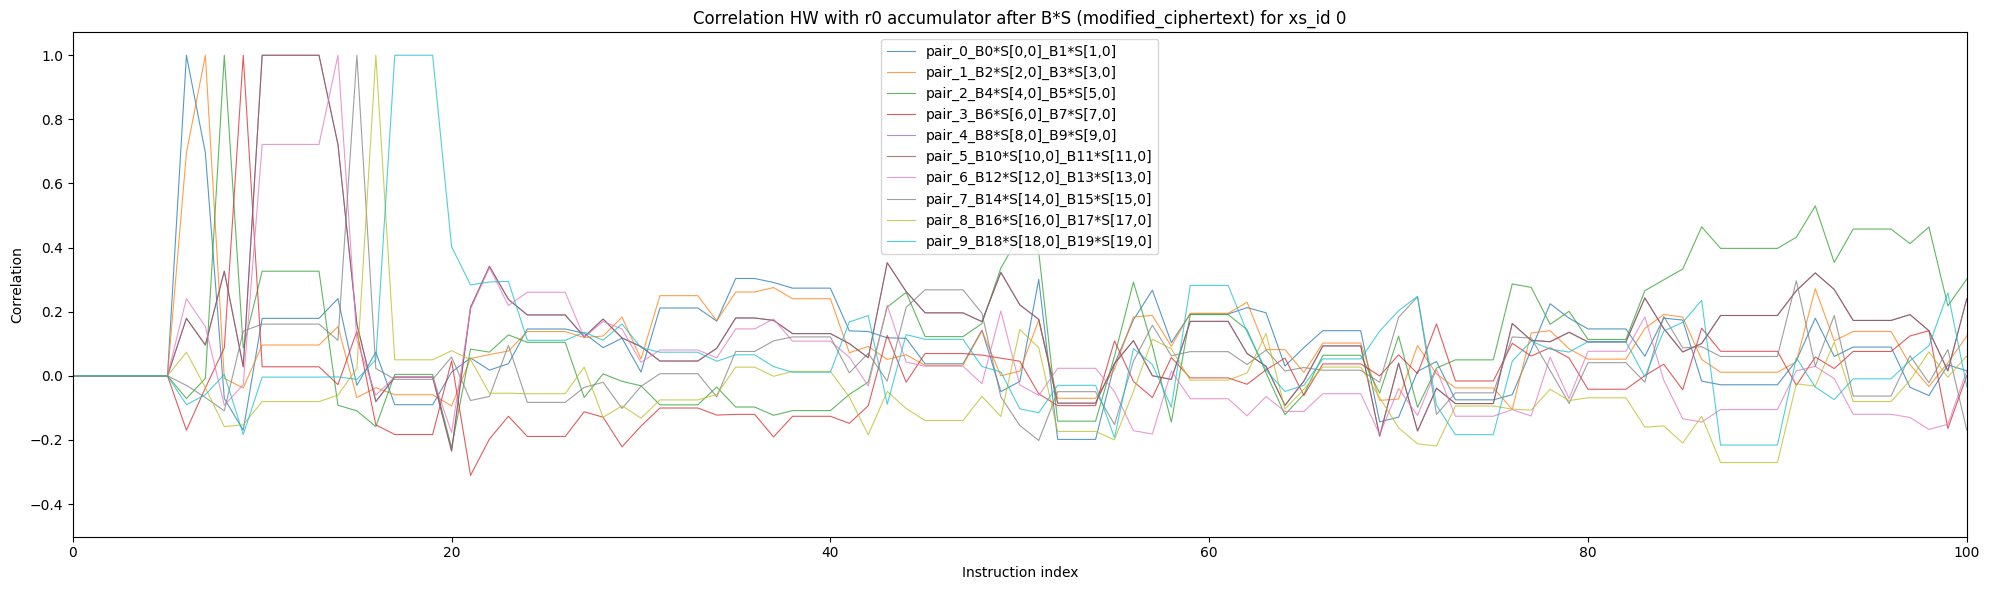

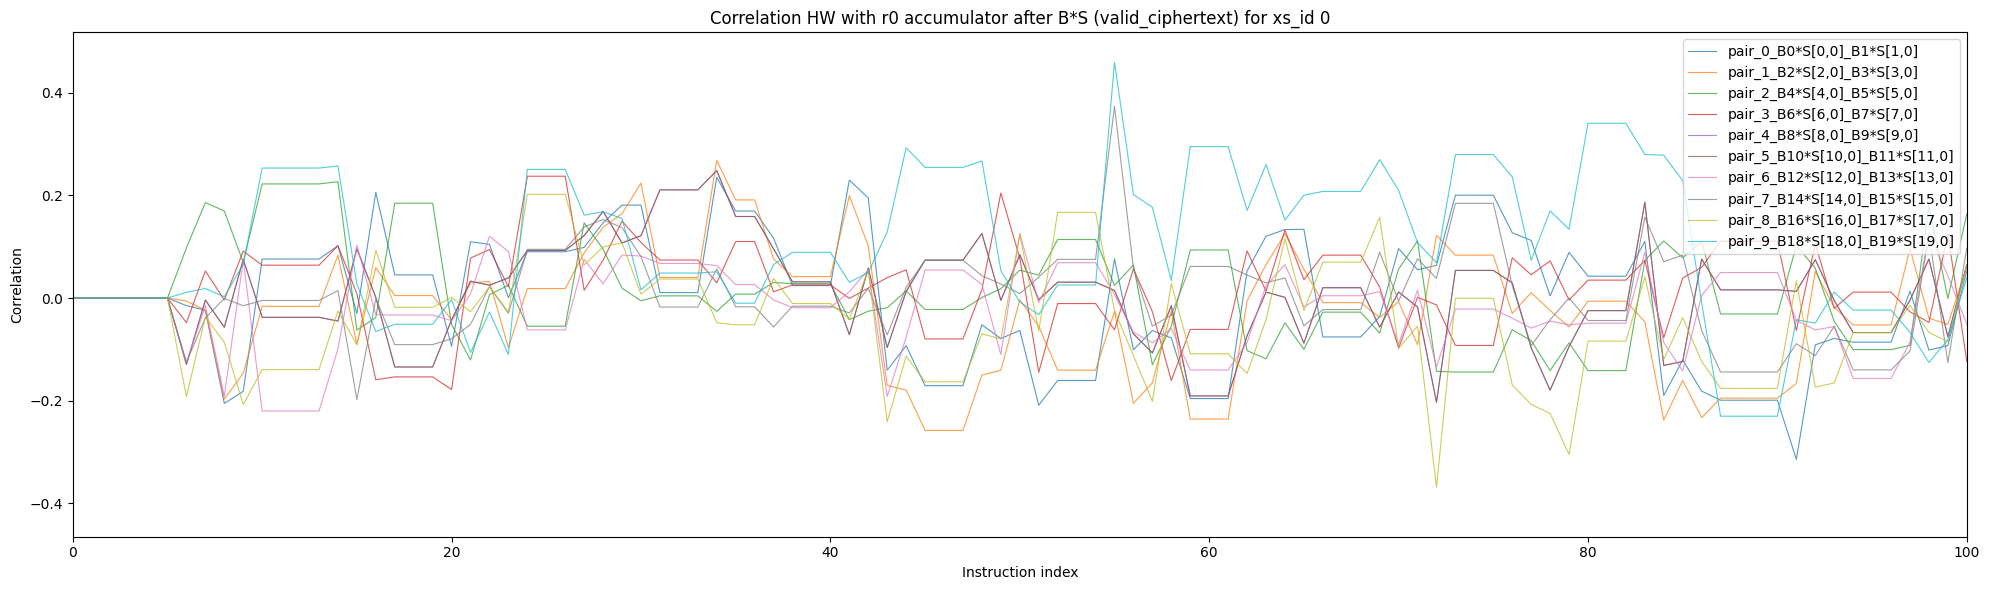

In [23]:
xs_id = 0
B_row = xs_id
no_pairs = 10

traces_hw_r0 = data_HW_r0[xs_id]

B_sets = {
    "modified_ciphertext": B_all,
    "valid_ciphertext": B_valid,
}

for B_name, B_values in B_sets.items():
    corr_hw_accumulator_array = {}
    r0_old = np.zeros(B_values.shape[0], dtype=np.int32)

    for pair_idx in range(no_pairs):
        B_col = 2 * pair_idx
        B_col_next = B_col + 1

        if B_col_next >= B_values.shape[2]:
            break

        S0 = int(S_real[B_col, xs_id])
        S1 = int(S_real[B_col_next, xs_id])

        pair_product = (
            B_values[:, B_row, B_col].astype(np.int32) * S0
            + B_values[:, B_row, B_col_next].astype(np.int32) * S1
        )

        r0_new = r0_old + pair_product
        target_hw_accumulator = hw_u32(r0_new & 0xffffffff)

        label = (
            f"pair_{pair_idx}_"
            f"B{B_col}*S[{B_col},{xs_id}]_"
            f"B{B_col_next}*S[{B_col_next},{xs_id}]"
        )

        corr_hw_accumulator_array[label] = compute_correlation(
            traces_hw_r0,
            target_hw_accumulator,
        )

        r0_old = r0_new

    plot_correlation(
        corr_hw_accumulator_array,
        f"Correlation HW with r0 accumulator after B*S ({B_name}) for xs_id {xs_id}",
        os.path.join(
            result_dir_truncated,
            f"correlation_HW_actual_BS_accumulator_{B_name}_xs{xs_id}.png",
        ),
        no_instructions=no_instructions,
    )

## Guess S by correlation


In [10]:
def print_best_guess(corr_array, label, local_sample_idx, real_instruction_idx):
    best_guess = None
    best_abs_corr = -1
    best_corr = None

    for guess_label, corr in corr_array.items():
        guess = int(guess_label.replace("S_", ""))
        corr = np.asarray(corr, dtype=np.float64)

        target_corr = float(corr[local_sample_idx])
        target_abs = abs(target_corr)

        if target_abs > best_abs_corr:
            best_guess = guess
            best_abs_corr = target_abs
            best_corr = target_corr

    print(f"{label} best guess: {best_guess}")
    print(f"{label} abs correlation at target: {best_abs_corr:.6f}")
    print(f"{label} signed correlation at target: {best_corr:.6f}")
    print(f"{label} real instruction index: {real_instruction_idx}")
    return best_guess

Value that we try to guess 

In [11]:
B_col = 0
B_row = 4
xs_id = 0

S_guesses = range(-10,11)

In [12]:
if B_col % 2 != 0:
    raise ValueError("B_col must be even because smlad uses pairs: [0,1], [2,3], ...")

B_col_next = B_col + 1
pair_idx = B_col // 2

# Create the actual pair 
S_true = int(S_real[B_col, xs_id])
S_true_next = int(S_real[B_col_next, xs_id])

print(f"True pair: S[{B_col},{xs_id}] = {S_true}, S[{B_col_next},{xs_id}] = {S_true_next}")

r0_old = np.zeros(B_all.shape[0], dtype=np.int32)

for prev_pair in range(pair_idx):
    k0 = 2 * prev_pair
    k1 = k0 + 1

    r0_old += (
        B_all[:, B_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
        + B_all[:, B_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
    )

trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}_{selected_fault_index}.csv")
trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()

smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()
smlads_per_xs_call = 320 # 640 // 2 
smlad_global_idx = B_row * smlads_per_xs_call + pair_idx
target_smlad_instruction = int(smlad_indices[smlad_global_idx])

print(f"pair_idx = {pair_idx}")
print(f"smlad_global_idx = {smlad_global_idx}")
print(f"target_smlad_instruction = {target_smlad_instruction}")

instructions_before = 0
instructions_after = 10

hw_target_real = target_smlad_instruction + 1
hd_target_real = target_smlad_instruction

hw_start = max(0, hw_target_real - instructions_before)
traces_hw_r0 = data_HW_r0[xs_id]
traces_hd_r0 = data_HD_r0[xs_id]

hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)

hd_start = max(0, hd_target_real - instructions_before)
hd_end = min(traces_hd_r0.shape[1], hd_target_real + instructions_after + 1)

traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
traces_hd_guess = traces_hd_r0[:, hd_start:hd_end]

hw_target_local = hw_target_real - hw_start
hd_target_local = hd_target_real - hd_start

pair_scores = []

for S_guess_0 in S_guesses:
    for S_guess_1 in S_guesses:
        pair_product = (
            B_all[:, B_row, B_col].astype(np.int32) * int(S_guess_0)
            + B_all[:, B_row, B_col_next].astype(np.int32) * int(S_guess_1)
        )

        r0_new = r0_old + pair_product

        target_hw = hw_u32(r0_new & 0xffffffff)
        target_hd = hw_u32((r0_old ^ r0_new) & 0xffffffff)

        corr_hw = compute_correlation(traces_hw_guess, target_hw)
        corr_hd = compute_correlation(traces_hd_guess, target_hd)

        hw_corr = corr_hw[hw_target_local]
        hd_corr = corr_hd[hd_target_local]

        pair_scores.append({
            "S0": S_guess_0,
            "S1": S_guess_1,
            "HW_score": abs(hw_corr),
            "HD_score": abs(hd_corr),
            "HW_corr": hw_corr,
            "HD_corr": hd_corr,
        })

pair_scores_hw = sorted(pair_scores, key=lambda x: x["HW_score"], reverse=True)
pair_scores_hd = sorted(pair_scores, key=lambda x: x["HD_score"], reverse=True)

best_hw = pair_scores_hw[0]
# best_hd = pair_scores_hd[0]

print(f"Best pair HW is: S0 = {best_hw['S0']}, S1 = {best_hw['S1']} with abs correlation {best_hw['HW_score']:.6f}")
# print(f"Best pair HD is: S0 = {best_hd['S0']}, S1 = {best_hd['S1']}")


True pair: S[0,0] = 3, S[1,0] = -3
pair_idx = 0
smlad_global_idx = 1280
target_smlad_instruction = 1813
Best pair HW is: S0 = 3, S1 = -3 with abs correlation 1.000000


## Packed S-Pair Rank Matrix

For each xs() call, compute the rank of the true of the pair that was obtained from the correlation


In [13]:
def find_true_pair_rank(B, title):    
    S_guesses = range(-10, 11)

    S_pair_rank_hw = np.full((8, B.shape[2] // 2), np.nan)

    rank_details = []
    smlads_per_xs_call = 320  # 640 // 2
    instructions_before = 0
    instructions_after = 10


    def rank_true_packed_pair(xs_id, pair_idx, b_row=None):
        if b_row is None:
            b_row = xs_id

        b_col = 2 * pair_idx
        b_col_next = b_col + 1

        S0_true = int(S_real[b_col, xs_id])
        S1_true = int(S_real[b_col_next, xs_id])

        r0_old = np.zeros(B.shape[0], dtype=np.int32)
        for prev_pair in range(pair_idx):
            k0 = 2 * prev_pair
            k1 = k0 + 1
            r0_old += (
                B[:, b_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
                + B[:, b_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
            )

        trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}_{selected_fault_index}.csv")
        trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
        smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

        smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
        target_smlad_instruction = int(smlad_indices[smlad_global_idx])

        hw_target_real = target_smlad_instruction + 1
        traces_hw_r0 = data_HW_r0[xs_id]

        hw_start = max(0, hw_target_real - instructions_before)
        hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)
        traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
        hw_target_local = hw_target_real - hw_start

        pair_scores = []
        for S_guess_0 in S_guesses:
            for S_guess_1 in S_guesses:
                pair_product = (
                    B[:, b_row, b_col].astype(np.int32) * int(S_guess_0)
                    + B[:, b_row, b_col_next].astype(np.int32) * int(S_guess_1)
                )
                r0_new = r0_old + pair_product
                target_hw = hw_u32(r0_new & 0xffffffff)
                corr_hw = compute_correlation(traces_hw_guess, target_hw)
                hw_corr = corr_hw[hw_target_local]

                pair_scores.append({
                    "S0": int(S_guess_0),
                    "S1": int(S_guess_1),
                    "HW_score": abs(hw_corr),
                    "HW_corr": hw_corr,
                })

        pair_scores_hw = sorted(pair_scores, key=lambda row: row["HW_score"], reverse=True)

        true_rank = None
        for rank, row in enumerate(pair_scores_hw, start=1):
            if (row["S0"], row["S1"]) == (S0_true, S1_true):
                true_rank = rank
                break

        best = pair_scores_hw[0]
        return {
            "xs_id": xs_id,
            "b_row": b_row,
            "pair_idx": pair_idx,
            "b_col": b_col,
            "b_col_next": b_col_next,
            "S0_true": S0_true,
            "S1_true": S1_true,
            "S0_best_hw": best["S0"],
            "S1_best_hw": best["S1"],
            "HW_rank_true_pair": true_rank,
        }

    for xs_id in range(8):
        print(f"Computing packed S-pair ranks for xs_id={xs_id}")
        for pair_idx in range(B.shape[2] // 2):
            result = rank_true_packed_pair(xs_id, pair_idx, b_row=xs_id)
            rank_details.append(result)

            S_pair_rank_hw[xs_id, pair_idx] = result["HW_rank_true_pair"]

            if pair_idx % 40 == 0:
                print(
                    f"  pair_idx={pair_idx:3}: true=({result['S0_true']},{result['S1_true']}), "
                    f"best=({result['S0_best_hw']},{result['S1_best_hw']}), "
                    f"rank={result['HW_rank_true_pair']}"
                )

    pair_columns = [f"S_pair_{i}" for i in range(B.shape[2] // 2)]

    rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)
    rank_df.index.name = "xs_id"
    rank_path = os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_{title}.csv")
    rank_df.to_csv(rank_path)


    print(f"Saved packed true-pair rank matrix to {rank_path}")

    print("Rank matrix summary:")
    print(rank_df.stack().describe())

find_true_pair_rank(B_all, "B_all")
find_true_pair_rank(B_valid, "B_valid")



Computing packed S-pair ranks for xs_id=0
  pair_idx=  0: true=(3,-3), best=(3,-3), rank=1
  pair_idx= 40: true=(1,2), best=(1,2), rank=1
  pair_idx= 80: true=(4,5), best=(4,5), rank=1
  pair_idx=120: true=(-3,-6), best=(-3,-6), rank=1
  pair_idx=160: true=(0,-2), best=(0,-2), rank=1
  pair_idx=200: true=(0,1), best=(0,1), rank=1
  pair_idx=240: true=(-3,0), best=(-3,0), rank=1
  pair_idx=280: true=(1,1), best=(1,1), rank=1
Computing packed S-pair ranks for xs_id=1
  pair_idx=  0: true=(-3,1), best=(-3,1), rank=1
  pair_idx= 40: true=(2,1), best=(2,1), rank=1
  pair_idx= 80: true=(2,-3), best=(2,-3), rank=1
  pair_idx=120: true=(-5,-2), best=(-5,-2), rank=1
  pair_idx=160: true=(0,-1), best=(0,-1), rank=1
  pair_idx=200: true=(4,3), best=(4,3), rank=1
  pair_idx=240: true=(-5,0), best=(-5,0), rank=1
  pair_idx=280: true=(1,-3), best=(1,-3), rank=1
Computing packed S-pair ranks for xs_id=2
  pair_idx=  0: true=(0,1), best=(0,1), rank=1
  pair_idx= 40: true=(0,5), best=(0,5), rank=1
  pa

/var/folders/9_/_gg94zdd64qdbw0dmll8z2y40000gn/T/ipykernel_96220/3609999111.py:104: RuntimeWarning: invalid value encountered in cast
  rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)


Saved packed true-pair rank matrix to Results_decapsulation_truncated/S_pair_rank_HW_packed_B_all.csv
Rank matrix summary:
count    2560.000000
mean        1.001953
std         0.065534
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
dtype: float64
Computing packed S-pair ranks for xs_id=0
  pair_idx=  0: true=(3,-3), best=(-10,0), rank=382
  pair_idx= 40: true=(1,2), best=(-8,-8), rank=325
  pair_idx= 80: true=(4,5), best=(-10,-6), rank=143
  pair_idx=120: true=(-3,-6), best=(3,-7), rank=337
  pair_idx=160: true=(0,-2), best=(-9,1), rank=264
  pair_idx=200: true=(0,1), best=(-8,-9), rank=295
  pair_idx=240: true=(-3,0), best=(-7,-6), rank=323
  pair_idx=280: true=(1,1), best=(-6,-8), rank=148
Computing packed S-pair ranks for xs_id=1
  pair_idx=  0: true=(-3,1), best=(-3,-9), rank=176
  pair_idx= 40: true=(2,1), best=(-8,-9), rank=224
  pair_idx= 80: true=(2,-3), best=(-1,-1), rank=398
  pair_idx=120: true=(-5,-2), best=(1,-9), 

/var/folders/9_/_gg94zdd64qdbw0dmll8z2y40000gn/T/ipykernel_96220/3609999111.py:104: RuntimeWarning: invalid value encountered in cast
  rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)


Calculate succes rate

In [14]:
S_pair_rank_hw = pd.read_csv(os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_B_all.csv"), index_col="xs_id").to_numpy(dtype=np.float64)
success_rate = np.count_nonzero(S_pair_rank_hw == 1) / np.count_nonzero(~np.isnan(S_pair_rank_hw))
print(f"Success rate of having the true pair as the top guess: {success_rate:.2%}")

S_pair_rank_hw_valid = pd.read_csv(os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_B_valid.csv"), index_col="xs_id").to_numpy(dtype=np.float64)
success_rate_valid = np.count_nonzero(S_pair_rank_hw_valid == 1) / np.count_nonzero(~np.isnan(S_pair_rank_hw_valid))
print(f"Success rate of having the true pair as the top guess (valid): {success_rate_valid:.2%}")


Success rate of having the true pair as the top guess: 99.80%
Success rate of having the true pair as the top guess (valid): 0.04%


## DPA Attack 


In [15]:
FAULT_INDICES_FOR_PAIRS = list(range(0, 320, 2))
S_GUESSES = range(-10, 11)
ATTACK_B_PREFIX = "B_from_registers_packed"


def load_hw_r0_for_fault(xs_id, fault_index, run_order, output_dir_trim="output_decapsulation_truncated_TRIM"):
    traces = []
    for run_index in run_order:
        trace_path = Path(output_dir_trim) / f"trace_{run_index}_{xs_id}_{fault_index}.csv"
        if not trace_path.exists():
            raise FileNotFoundError(f"Missing trace: {trace_path}")
        traces.append(create_HW_trace(trace_path, ["r0"]))

    min_len = min(len(trace) for trace in traces)
    return np.array([trace[:min_len] for trace in traces])


def smlad_hw_index(xs_id, b_row, pair_idx, fault_index, reference_run=0, output_dir_trim="output_decapsulation_truncated_TRIM"):
    trace_path = Path(output_dir_trim) / f"trace_{reference_run}_{xs_id}_{fault_index}.csv"
    trace_df = pd.read_csv(trace_path)
    trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
    smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

    smlads_per_xs_call = 320
    smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
    return int(smlad_indices[smlad_global_idx]) + 1


def unpack_i16_pair_from_u32(x):
    x = np.asarray(x, dtype=np.uint32)
    low = (x & 0xffff).astype(np.int32)
    high = ((x >> 16) & 0xffff).astype(np.int32)

    low = np.where(low >= 0x8000, low - 0x10000, low)
    high = np.where(high >= 0x8000, high - 0x10000, high)
    return low, high


def score_pair_guess(B_packed_fault, b_row, pair_idx, r0_old, traces_hw, hw_local_index, S0_guess, S1_guess):
    B_packed = B_packed_fault[:, b_row, pair_idx]
    B0, B1 = unpack_i16_pair_from_u32(B_packed)

    pair_product = B0 * int(S0_guess) + B1 * int(S1_guess)
    r0_guess = r0_old + pair_product
    target_hw = hw_u32(r0_guess & 0xffffffff)
    corr = compute_correlation(traces_hw, target_hw)[hw_local_index]
    return abs(corr), corr, pair_product


def rank_of_true_pair(scores, S0_true, S1_true):
    for rank, row in enumerate(scores, start=1):
        if (row["S0"], row["S1"]) == (S0_true, S1_true):
            return rank, row["score"], row["corr"]
    return np.nan, np.nan, np.nan


def accumulator_attack(xs_ids=range(8), fault_indices=FAULT_INDICES_FOR_PAIRS, S_guesses=S_GUESSES, instructions_before=0, instructions_after=10, max_runs=None):
    
    B_by_fault = {}
    runs_by_fault = {}
    for fault_index in fault_indices:
        B_by_fault[fault_index], runs_by_fault[fault_index] = load_all_B( B_folder, prefix=ATTACK_B_PREFIX, fault_index=fault_index)

    all_runs = runs_by_fault[fault_indices[0]]
    for fault_index in fault_indices[1:]:
        if runs_by_fault[fault_index] != all_runs:
            raise ValueError(f"Run order mismatch for fault_index={fault_index}")

    if max_runs is None:
        selected_positions = np.arange(len(all_runs))
    else:
        selected_positions = np.arange(min(max_runs, len(all_runs)))

    selected_runs = [all_runs[pos] for pos in selected_positions]

    recovered = np.empty((8, len(fault_indices)), dtype=object)
    true_values = np.empty((8, len(fault_indices)), dtype=object)
    true_ranks = np.full((8, len(fault_indices)), np.nan)
    details = []

    for xs_id in xs_ids:
        b_row = xs_id
        print(f"xs_id={xs_id}")

        for pair_idx, fault_index in enumerate(fault_indices):
            expected_fault_index = 2 * pair_idx
            if fault_index != expected_fault_index:
                raise ValueError(
                    f"There is a mismatch: "
                    f"pair_idx={pair_idx}, fault_index={fault_index}, expected={expected_fault_index}"
                )

            b_col = fault_index
            B_fault = B_by_fault[fault_index][selected_positions]
            r0_old = np.zeros(len(selected_runs), dtype=np.int32)

            hw_index = smlad_hw_index(xs_id=xs_id, b_row=b_row, pair_idx=pair_idx, fault_index=fault_index, reference_run=selected_runs[0])
            traces_hw = load_hw_r0_for_fault(xs_id, fault_index, selected_runs)
            start = max(0, hw_index - instructions_before)
            end = min(traces_hw.shape[1], hw_index + instructions_after + 1)
            traces_window = traces_hw[:, start:end]
            hw_local_index = hw_index - start

            scores = []
            for S0_guess in S_guesses:
                for S1_guess in S_guesses:
                    score, corr, pair_product = score_pair_guess(
                        B_fault,
                        b_row,
                        pair_idx,
                        r0_old,
                        traces_window,
                        hw_local_index,
                        S0_guess,
                        S1_guess,
                    )
                    scores.append({
                        "S0": int(S0_guess),
                        "S1": int(S1_guess),
                        "score": score,
                        "corr": corr,
                    })

            scores.sort(key=lambda row: row["score"], reverse=True)
            best = scores[0]
            best_S0, best_S1 = best["S0"], best["S1"]

            S0_true = int(S_real[b_col, xs_id])
            S1_true = int(S_real[b_col + 1, xs_id])
            true_rank, true_score, true_corr = rank_of_true_pair(scores, S0_true, S1_true)

            recovered[xs_id, pair_idx] = f"({best_S0},{best_S1})"
            true_values[xs_id, pair_idx] = f"({S0_true},{S1_true})"
            true_ranks[xs_id, pair_idx] = true_rank

            details.append({
                "xs_id": xs_id,
                "pair_idx": pair_idx,
                "fault_index": fault_index,
                "b_col": b_col,
                "S0_best": best_S0,
                "S1_best": best_S1,
                "S0_true": S0_true,
                "S1_true": S1_true,
                "true_rank": true_rank,
                "best_score": best["score"],
                "true_score": true_score,
                "best_corr": best["corr"],
                "true_corr": true_corr,
                "hw_index": hw_index,
            })

            print(
                f"pair={pair_idx}, fault={fault_index}, "
                f"best=({best_S0},{best_S1}), true=({S0_true},{S1_true}), rank={true_rank}"
            )

    pair_columns = [f"S_pair_{i}" for i in range(len(fault_indices))]
    recovered_df = pd.DataFrame(recovered, columns=pair_columns)
    true_df = pd.DataFrame(true_values, columns=pair_columns)
    rank_df = pd.DataFrame(true_ranks, columns=pair_columns)

    for df in [recovered_df, true_df, rank_df]:
        df.index.name = "xs_id"

    os.makedirs(result_dir_truncated, exist_ok=True)
    rank_df.to_csv(os.path.join(result_dir_truncated, "S_pair_true_rank_modified_accumulator_HW.csv"))

    success_rate = np.count_nonzero(true_ranks == 1) / np.count_nonzero(~np.isnan(true_ranks))
    print(f"Success rate with {len(selected_runs)} traces: {success_rate:.2%}")

    return recovered_df, rank_df


recovered_modified_df, rank_modified_df = accumulator_attack()


xs_id=0
pair=0, fault=0, best=(3,-3), true=(3,-3), rank=1
pair=1, fault=2, best=(0,1), true=(0,1), rank=1
pair=2, fault=4, best=(-10,-6), true=(-5,-3), rank=2
pair=3, fault=6, best=(-6,-2), true=(-3,-1), rank=2
pair=4, fault=8, best=(3,2), true=(3,2), rank=1
pair=5, fault=10, best=(-10,-10), true=(0,0), rank=221
pair=6, fault=12, best=(-2,2), true=(-2,2), rank=1
pair=7, fault=14, best=(-3,3), true=(-3,3), rank=1
pair=8, fault=16, best=(-6,-1), true=(-6,-1), rank=1
pair=9, fault=18, best=(-3,4), true=(-3,4), rank=1
pair=10, fault=20, best=(-4,5), true=(-4,5), rank=1
pair=11, fault=22, best=(-3,7), true=(-3,7), rank=1
pair=12, fault=24, best=(-1,1), true=(-1,1), rank=1
pair=13, fault=26, best=(0,-8), true=(0,-1), rank=4
pair=14, fault=28, best=(4,1), true=(4,1), rank=1
pair=15, fault=30, best=(1,1), true=(2,2), rank=2
pair=16, fault=32, best=(0,-8), true=(0,-1), rank=4
pair=17, fault=34, best=(-2,2), true=(-2,2), rank=1
pair=18, fault=36, best=(7,-1), true=(7,-1), rank=1
pair=19, fault=3

## DPA Attack With Valid B


In [16]:
VALID_PAIR_INDICES = list(range(0, 320, 2))
VALID_B_PREFIX = "B_valid_from_registers_packed"


def load_hw_r0_valid(xs_id, run_order, output_dir_trim="output_decapsulation_truncated_TRIM"):
    traces = []
    for run_index in run_order:
        trace_path = Path(output_dir_trim) / f"trace_valid_{run_index}_{xs_id}.csv"
        if not trace_path.exists():
            raise FileNotFoundError(f"Missing valid trace: {trace_path}")
        traces.append(create_HW_trace(trace_path, ["r0"]))

    min_len = min(len(trace) for trace in traces)
    return np.array([trace[:min_len] for trace in traces])


def smlad_hw_index_valid(xs_id, b_row, pair_idx, reference_run=0, output_dir_trim="output_decapsulation_truncated_TRIM"):
    trace_path = Path(output_dir_trim) / f"trace_valid_{reference_run}_{xs_id}.csv"
    if not trace_path.exists():
        raise FileNotFoundError(f"Missing valid trace: {trace_path}")

    trace_df = pd.read_csv(trace_path)
    trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
    smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

    smlads_per_xs_call = 320
    smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
    return int(smlad_indices[smlad_global_idx]) + 1


def accumulator_attack_valid(xs_ids=range(8), pair_indices=VALID_PAIR_INDICES, S_guesses=S_GUESSES, instructions_before=0, instructions_after=10):
    B_valid_packed, valid_runs = load_all_B(B_folder, prefix=VALID_B_PREFIX)

    recovered = np.empty((8, len(pair_indices)), dtype=object)
    true_values = np.empty((8, len(pair_indices)), dtype=object)
    true_ranks = np.full((8, len(pair_indices)), np.nan)
    details = []

    for xs_id in xs_ids:
        b_row = xs_id
        r0_old = np.zeros(len(valid_runs), dtype=np.int32)
        traces_hw = load_hw_r0_valid(xs_id, valid_runs)
        print(f"valid xs_id={xs_id}")

        for col_idx, pair_idx in enumerate(pair_indices):
            b_col = 2 * pair_idx
            hw_index = smlad_hw_index_valid(
                xs_id=xs_id,
                b_row=b_row,
                pair_idx=pair_idx,
                reference_run=valid_runs[0],
            )
            start = max(0, hw_index - instructions_before)
            end = min(traces_hw.shape[1], hw_index + instructions_after + 1)
            traces_window = traces_hw[:, start:end]
            hw_local_index = hw_index - start

            scores = []
            for S0_guess in S_guesses:
                for S1_guess in S_guesses:
                    score, corr, _ = score_pair_guess(
                        B_valid_packed,
                        b_row,
                        pair_idx,
                        r0_old,
                        traces_window,
                        hw_local_index,
                        S0_guess,
                        S1_guess,
                    )
                    scores.append({
                        "S0": int(S0_guess),
                        "S1": int(S1_guess),
                        "score": score,
                        "corr": corr,
                    })

            scores.sort(key=lambda row: row["score"], reverse=True)
            best = scores[0]
            best_S0, best_S1 = best["S0"], best["S1"]

            _, _, best_pair_product = score_pair_guess(
                B_valid_packed,
                b_row,
                pair_idx,
                r0_old,
                traces_window,
                hw_local_index,
                best_S0,
                best_S1,
            )
            r0_old = r0_old + best_pair_product

            S0_true = int(S_real[b_col, xs_id])
            S1_true = int(S_real[b_col + 1, xs_id])
            true_rank, true_score, true_corr = rank_of_true_pair(scores, S0_true, S1_true)

            recovered[xs_id, col_idx] = f"({best_S0},{best_S1})"
            true_values[xs_id, col_idx] = f"({S0_true},{S1_true})"
            true_ranks[xs_id, col_idx] = true_rank

            details.append({
                "xs_id": xs_id,
                "pair_idx": pair_idx,
                "b_col": b_col,
                "S0_best": best_S0,
                "S1_best": best_S1,
                "S0_true": S0_true,
                "S1_true": S1_true,
                "true_rank": true_rank,
                "best_score": best["score"],
                "true_score": true_score,
                "best_corr": best["corr"],
                "true_corr": true_corr,
                "hw_index": hw_index,
            })

            print(
                f"pair={pair_idx}, best=({best_S0},{best_S1}), "
                f"true=({S0_true},{S1_true}), rank={true_rank}"
            )

    pair_columns = [f"S_pair_{pair_idx}" for pair_idx in pair_indices]
    recovered_df = pd.DataFrame(recovered, columns=pair_columns)
    true_df = pd.DataFrame(true_values, columns=pair_columns)
    rank_df = pd.DataFrame(true_ranks, columns=pair_columns)
    details_df = pd.DataFrame(details)

    for df in [recovered_df, true_df, rank_df]:
        df.index.name = "xs_id"

    os.makedirs(result_dir_truncated, exist_ok=True)
    # recovered_df.to_csv(os.path.join(result_dir_truncated, "S_pair_recovered_progressive_HW_valid.csv"))
    # true_df.to_csv(os.path.join(result_dir_truncated, "S_pair_true_progressive_HW_valid.csv"))
    rank_df.to_csv(os.path.join(result_dir_truncated, "S_pair_true_rank_accumulator_HW_valid.csv"))

    success_rate = np.count_nonzero(true_ranks == 1) / np.count_nonzero(~np.isnan(true_ranks))
    print(f"Valid progressive attack success rate: {success_rate:.2%}")

    return recovered_df, rank_df, details_df


recovered_valid_df, rank_valid_df, details_valid_df = accumulator_attack_valid()


valid xs_id=0
pair=0, best=(3,-3), true=(3,-3), rank=1
pair=2, best=(-3,-5), true=(-5,-3), rank=9
pair=4, best=(6,-2), true=(3,2), rank=29
pair=6, best=(-8,5), true=(-2,2), rank=26
pair=8, best=(-8,-3), true=(-6,-1), rank=37
pair=10, best=(-6,8), true=(-4,5), rank=85
pair=12, best=(2,7), true=(-1,1), rank=191
pair=14, best=(4,1), true=(4,1), rank=1
pair=16, best=(9,-8), true=(0,-1), rank=134
pair=18, best=(4,3), true=(7,-1), rank=12
pair=20, best=(0,0), true=(-1,-1), rank=11
pair=22, best=(9,3), true=(0,0), rank=207
pair=24, best=(8,-8), true=(-3,3), rank=82
pair=26, best=(-9,2), true=(0,-4), rank=382
pair=28, best=(-10,7), true=(3,-2), rank=145
pair=30, best=(0,0), true=(0,1), rank=17
pair=32, best=(-10,-6), true=(-2,-4), rank=109
pair=34, best=(1,-10), true=(-1,-4), rank=42
pair=36, best=(-1,4), true=(2,4), rank=140
pair=38, best=(-5,-9), true=(-4,-1), rank=156
pair=40, best=(-1,6), true=(1,2), rank=177
pair=42, best=(3,6), true=(2,3), rank=235
pair=44, best=(4,-3), true=(-2,-1), ran

# Combination between unmodified and modified

In [17]:
B_PREFIX = "B_from_registers_packed"
BASE_FAULT_INDEX = 0
COMBINED_FAULT_INDICES_FOR_PAIRS = FAULT_INDICES_FOR_PAIRS


def load_combined_modified_base_inputs(fault_indices, base_fault_index=BASE_FAULT_INDEX, max_runs=None):
    all_needed_faults = sorted(set(fault_indices) | {base_fault_index})
    B_by_fault = {}
    runs_by_fault = {}

    for fault_index in all_needed_faults:
        B_by_fault[fault_index], runs_by_fault[fault_index] = load_all_B( B_folder, prefix=B_PREFIX, fault_index=fault_index)

    selected_runs = list(runs_by_fault[base_fault_index])
    if max_runs is not None:
        selected_runs = selected_runs[:max_runs]

    no_selected_runs = len(selected_runs)
    B_by_fault = {
        fault_index: B_by_fault[fault_index][:no_selected_runs]
        for fault_index in all_needed_faults
    }

    return B_by_fault, selected_runs


def score_candidate_on_base_trace(candidate, B_base,b_row, pair_idx, r0_old_base, base_traces_window, base_hw_local_index):
    base_score, base_corr, base_pair_product = score_pair_guess(B_base, b_row, pair_idx, r0_old_base, base_traces_window, base_hw_local_index, candidate["S0"], candidate["S1"])
    
    return base_score, base_corr, base_pair_product


def choose_candidate_with_base_check(modified_scores, B_base, b_row, pair_idx, r0_old_base, base_traces_window, base_hw_local_index, max_candidates_to_check=None):
    checked = []
    candidates = modified_scores if max_candidates_to_check is None else modified_scores[:max_candidates_to_check]

    for modified_rank, candidate in enumerate(candidates, start=1):
        base_score, base_corr, base_pair_product = score_candidate_on_base_trace(
            candidate,
            B_base,
            b_row,
            pair_idx,
            r0_old_base,
            base_traces_window,
            base_hw_local_index,
        )
        checked.append({
            **candidate,
            "modified_rank": modified_rank,
            "base_score": base_score,
            "base_corr": base_corr,
            "base_pair_product": base_pair_product,
        })

    best_base = max(checked, key=lambda row: row["base_score"])
    return best_base


def combined_modified_base_attack(
    xs_ids=range(8),
    fault_indices=COMBINED_FAULT_INDICES_FOR_PAIRS,
    base_fault_index=BASE_FAULT_INDEX,
    S_guesses=S_GUESSES,
    instructions_before=0,
    instructions_after=10,
    max_runs=None,
    max_candidates_to_check=None,
    retry_base_score_threshold=0.9995,
):
    """
    1. Check each pair independantly with their traces
    2. Check is the found candidate produces a good correlation with the modified ciohertext with fault_index=0

    E.g. the pair ranked from trace_<run>_<xs>_2.csv is checked on
    trace_<run>_<xs>_0.csv, not on trace_valid_<run>_<xs>.csv.
    The accepted pair is the candidate with maximum base-trace correlation.

    3. If the base check drops below retry_base_score_threshold,
    try with a different first pair 
    """
    B_by_fault, selected_runs = load_combined_modified_base_inputs(
        fault_indices,
        base_fault_index=base_fault_index,
        max_runs=max_runs,
    )
    B_base = B_by_fault[base_fault_index]

    recovered = np.empty((8, len(fault_indices)), dtype=object)
    true_values = np.empty((8, len(fault_indices)), dtype=object)
    true_ranks = np.full((8, len(fault_indices)), np.nan)
    accepted_modified_ranks = np.full((8, len(fault_indices)), np.nan)
    accepted_base_scores = np.full((8, len(fault_indices)), np.nan)
    accepted_threshold_flags = np.full((8, len(fault_indices)), False)
    all_details = []

    def run_xs_chain(xs_id, force_first_pair_rank=1):
        b_row = xs_id
        r0_old_base = np.zeros(len(selected_runs), dtype=np.int32)
        base_traces_hw = load_hw_r0_for_fault(xs_id, base_fault_index, selected_runs)

        xs_recovered = np.full(len(fault_indices), "not_run", dtype=object)
        xs_true_values = np.full(len(fault_indices), "not_run", dtype=object)
        xs_true_ranks = np.full(len(fault_indices), np.nan)
        xs_accepted_modified_ranks = np.full(len(fault_indices), np.nan)
        xs_accepted_base_scores = np.full(len(fault_indices), np.nan)
        xs_accepted_threshold_flags = np.full(len(fault_indices), False)
        xs_details = []
        retry_triggered = False
        retry_pair_idx = None
        retry_base_score = None

        for pair_idx, fault_index in enumerate(fault_indices):
            expected_fault_index = 2 * pair_idx
            if fault_index != expected_fault_index:
                raise ValueError(
                    f"fault_index must isolate the current packed pair: "
                    f"pair_idx={pair_idx}, fault_index={fault_index}, expected={expected_fault_index}"
                )

            b_col = fault_index
            B_modified = B_by_fault[fault_index]
            r0_accumulator0 = np.zeros(len(selected_runs), dtype=np.int32)

            modified_hw_index = smlad_hw_index(
                xs_id=xs_id,
                b_row=b_row,
                pair_idx=pair_idx,
                fault_index=fault_index,
                reference_run=selected_runs[0],
            )
            modified_traces_hw = load_hw_r0_for_fault(xs_id, fault_index, selected_runs)
            modified_start = max(0, modified_hw_index - instructions_before)
            modified_end = min(modified_traces_hw.shape[1], modified_hw_index + instructions_after + 1)
            modified_window = modified_traces_hw[:, modified_start:modified_end]
            modified_hw_local_index = modified_hw_index - modified_start

            modified_scores = []
            for S0_guess in S_guesses:
                for S1_guess in S_guesses:
                    score, corr, pair_product = score_pair_guess(
                        B_modified,
                        b_row,
                        pair_idx,
                        r0_accumulator0,
                        modified_window,
                        modified_hw_local_index,
                        S0_guess,
                        S1_guess,
                    )
                    modified_scores.append({
                        "S0": int(S0_guess),
                        "S1": int(S1_guess),
                        "score": score,
                        "corr": corr,
                        "pair_product": pair_product,
                    })

            modified_scores.sort(key=lambda row: row["score"], reverse=True)

            base_hw_index = smlad_hw_index(
                xs_id=xs_id,
                b_row=b_row,
                pair_idx=pair_idx,
                fault_index=base_fault_index,
                reference_run=selected_runs[0],
            )
            base_start = max(0, base_hw_index - instructions_before)
            base_end = min(base_traces_hw.shape[1], base_hw_index + instructions_after + 1)
            base_window = base_traces_hw[:, base_start:base_end]
            base_hw_local_index = base_hw_index - base_start

            if fault_index == base_fault_index:
                forced_index = min(force_first_pair_rank - 1, len(modified_scores) - 1)
                best_modified = modified_scores[forced_index]
                base_score, base_corr, base_pair_product = score_candidate_on_base_trace(
                    best_modified,
                    B_base,
                    b_row,
                    pair_idx,
                    r0_old_base,
                    base_window,
                    base_hw_local_index,
                )
                accepted = {
                    **best_modified,
                    "modified_rank": forced_index + 1,
                    "base_score": base_score,
                    "base_corr": base_corr,
                    "base_pair_product": base_pair_product,
                }
            else:
                accepted = choose_candidate_with_base_check(
                    modified_scores,
                    B_base,
                    b_row,
                    pair_idx,
                    r0_old_base,
                    base_window,
                    base_hw_local_index,
                    max_candidates_to_check=max_candidates_to_check,
                )

            S0_true = int(S_real[b_col, xs_id])
            S1_true = int(S_real[b_col + 1, xs_id])
            true_rank, _, _ = rank_of_true_pair(modified_scores, S0_true, S1_true)

            r0_old_base = r0_old_base + accepted["base_pair_product"]

            xs_recovered[pair_idx] = f"({accepted['S0']},{accepted['S1']})"
            xs_true_values[pair_idx] = f"({S0_true},{S1_true})"
            xs_true_ranks[pair_idx] = true_rank
            xs_accepted_modified_ranks[pair_idx] = accepted["modified_rank"]
            xs_accepted_base_scores[pair_idx] = accepted["base_score"]
            xs_accepted_threshold_flags[pair_idx] = accepted["base_score"] >= retry_base_score_threshold

            if accepted["base_score"] < retry_base_score_threshold:
                retry_triggered = True
                retry_pair_idx = pair_idx
                retry_base_score = accepted["base_score"]

            xs_details.append({
                "xs_id": xs_id,
                "pair_idx": pair_idx,
                "fault_index": fault_index,
                "b_col": b_col,
                "force_first_pair_rank": force_first_pair_rank,
                "S0_accepted": accepted["S0"],
                "S1_accepted": accepted["S1"],
                "S0_true": S0_true,
                "S1_true": S1_true,
                "accepted_is_true": (accepted["S0"], accepted["S1"]) == (S0_true, S1_true),
                "accepted_modified_rank": accepted["modified_rank"],
                "accepted_modified_corr": accepted["corr"],
            })

            print(
                f"pair={pair_idx}, modified_fault={fault_index}, base_fault={base_fault_index}, "
                f"accepted=({accepted['S0']},{accepted['S1']}) "
                f"mod_rank={accepted['modified_rank']} base_score={accepted['base_score']:.4f}, "
                f"true=({S0_true},{S1_true}), true_mod_rank={true_rank}"
            )

            if retry_triggered:
                print(
                    f"[EARLY STOP] xs_id={xs_id}, pair={pair_idx}: "
                    f"base_score={retry_base_score:.4f} < {retry_base_score_threshold}."
                )
                break

        return {
            "recovered": xs_recovered,
            "true_values": xs_true_values,
            "true_ranks": xs_true_ranks,
            "accepted_modified_ranks": xs_accepted_modified_ranks,
            "accepted_base_scores": xs_accepted_base_scores,
            "accepted_threshold_flags": xs_accepted_threshold_flags,
            "details": xs_details,
            "retry_triggered": retry_triggered,
            "retry_pair_idx": retry_pair_idx,
            "retry_base_score": retry_base_score,
        }

    for xs_id in xs_ids:
        print(f"combined modified/base xs_id={xs_id}")
        first_pair_rank = 1
        result = run_xs_chain(xs_id, force_first_pair_rank=first_pair_rank)

        while result["retry_triggered"]:
            first_pair_rank += 1
            if first_pair_rank > len(S_guesses) ** 2:
                print(
                    f"[RETRY STOP] xs_id={xs_id}: no more first-pair candidates after "
                    f"rank {first_pair_rank - 1}. Keeping the last result."
                )
                break

            print(
                f"[RETRY] xs_id={xs_id}: base_score={result['retry_base_score']:.4f} "
                f"at pair={result['retry_pair_idx']} < {retry_base_score_threshold}. "
                f"Retrying with pair 0 forced to modified candidate rank {first_pair_rank}."
            )
            result = run_xs_chain(xs_id, force_first_pair_rank=first_pair_rank)

        recovered[xs_id, :] = result["recovered"]
        true_values[xs_id, :] = result["true_values"]
        true_ranks[xs_id, :] = result["true_ranks"]
        accepted_modified_ranks[xs_id, :] = result["accepted_modified_ranks"]
        accepted_base_scores[xs_id, :] = result["accepted_base_scores"]
        accepted_threshold_flags[xs_id, :] = result["accepted_threshold_flags"]
        all_details.extend(result["details"])

    details_df = pd.DataFrame(all_details)

    os.makedirs(result_dir_truncated, exist_ok=True)
    
    details_df.to_csv(os.path.join(result_dir_truncated, "S_pair_combined_modified_base_details.csv"), index=False)

    success_rate = details_df.groupby("xs_id").tail(len(fault_indices))["accepted_is_true"].mean()
    print(f"Success rate with {len(selected_runs)} traces: {success_rate:.2%}")

    return details_df


details_combined_df = combined_modified_base_attack(max_runs=None,max_candidates_to_check=None,retry_base_score_threshold=0.9995,)


combined modified/base xs_id=0
pair=0, modified_fault=0, base_fault=0, accepted=(3,-3) mod_rank=1 base_score=1.0000, true=(3,-3), true_mod_rank=1
pair=1, modified_fault=2, base_fault=0, accepted=(0,1) mod_rank=1 base_score=1.0000, true=(0,1), true_mod_rank=1
pair=2, modified_fault=4, base_fault=0, accepted=(-5,-3) mod_rank=2 base_score=1.0000, true=(-5,-3), true_mod_rank=2
pair=3, modified_fault=6, base_fault=0, accepted=(-3,-1) mod_rank=2 base_score=1.0000, true=(-3,-1), true_mod_rank=2
pair=4, modified_fault=8, base_fault=0, accepted=(3,2) mod_rank=1 base_score=1.0000, true=(3,2), true_mod_rank=1
pair=5, modified_fault=10, base_fault=0, accepted=(0,0) mod_rank=221 base_score=1.0000, true=(0,0), true_mod_rank=221
pair=6, modified_fault=12, base_fault=0, accepted=(-2,2) mod_rank=1 base_score=1.0000, true=(-2,2), true_mod_rank=1
pair=7, modified_fault=14, base_fault=0, accepted=(-3,3) mod_rank=1 base_score=1.0000, true=(-3,3), true_mod_rank=1
pair=8, modified_fault=16, base_fault=0, acc